## Import Libraries

In [3]:
!pip install -q sentence-transformers

In [5]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [6]:
df = pd.read_csv("../data/final_feature_dataset.csv")

print(df.shape)

df.head()

(3500, 16)


,ResumeID,Category,Skills,Education,Experience,Clean_Text,Text,Source,Resume_Length,Word_Count,Sentence_Count,Skill_Count,Education_Length,Experience_Length,Source_Encoded,Category_Encoded
0,REAL_0001,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,ResumeAtlas,1495,189,1,4,3,64,0,17
1,REAL_0002,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer linkedincomi...,jared arthur maica java developer 17994568777 ...,ResumeAtlas,1686,206,1,4,3,62,0,17
2,REAL_0003,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,5555,715,1,4,3,62,0,17
3,REAL_0004,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,12834,1657,1,4,3,61,0,17
4,REAL_0005,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,4181,489,1,4,3,57,0,17


## Load Pretrained Model

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence Transformer Loaded Successfully")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\alokj\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alokj\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer Loaded Successfully


## Select One Resume

In [8]:
resume_text = df.loc[0, "Clean_Text"]

print(resume_text[:800])

jessica claire montgomery street san francisco ca resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior java developertech lead 2014 current synnex corporation tracy ca java developer agile scrum team javascript java develop customer facing internal web applications underlying component applications wrote maintainable extensible code team environment implemented designs including experimentation multiple iterations system administrator mantech international corporation joint base mcguire nj technical lead system administrator oracle ebusiness suite erp application mentored technical staff java developerscada system ad


## Create Sample Job Description

In [9]:
job_description = """
We are looking for a Python Developer with experience in
Python,
Machine Learning,
SQL,
Git,
Docker,
REST API,
AWS.

Candidate should have strong problem solving and communication skills.
"""

print(job_description)


We are looking for a Python Developer with experience in
Python,
Machine Learning,
SQL,
Git,
Docker,
REST API,
AWS.

Candidate should have strong problem solving and communication skills.



## Generate Resume Embedding

In [10]:
resume_embedding = model.encode(
    resume_text,
    convert_to_numpy=True
)

print(resume_embedding.shape)

(384,)


## Generate JD Embedding

In [12]:
jd_embedding = model.encode(
    job_description,
    convert_to_numpy=True
)

print(jd_embedding.shape)

(384,)


## Calculate Similarity

In [13]:
similarity = cosine_similarity(
    [resume_embedding],
    [jd_embedding]
)

print(similarity)

[[0.31612882]]


## Convert to Percentage

In [14]:
match_score = similarity[0][0] * 100

print(f"Resume Match Score : {match_score:.2f}%")

Resume Match Score : 31.61%


## Match Category

In [15]:
if match_score >= 85:
    print("Excellent Match")

elif match_score >= 70:
    print("Good Match")

elif match_score >= 50:
    print("Average Match")

else:
    print("Low Match")

Low Match


## Final Summary

In [17]:
print("=" * 50)
print("Semantic Resume Matching Completed")
print(f"Match Score : {match_score:.2f}%")
print("=" * 50)

Semantic Resume Matching Completed
Match Score : 31.61%


# Conclusion

- Loaded Sentence Transformer Model
- Generated Resume Embedding
- Generated Job Description Embedding
- Calculated Cosine Similarity
- Generated Resume Match Score
- Classified Match Level

## Create Function

In [19]:
def calculate_match_score(resume_text, job_description):

    resume_embedding = model.encode(
        resume_text,
        convert_to_numpy=True
    )

    jd_embedding = model.encode(
        job_description,
        convert_to_numpy=True
    )

    similarity = cosine_similarity(
        [resume_embedding],
        [jd_embedding]
    )

    return similarity[0][0] * 100

## Test Function

In [20]:
resume = df.loc[5, "Clean_Text"]

job_description = """
Looking for a Python Developer with experience in Python,
Machine Learning,
SQL,
Git,
Docker,
REST API,
AWS.
"""

score = calculate_match_score(
    resume,
    job_description
)

print(f"Match Score : {score:.2f}%")

Match Score : 38.91%


## Match Category Function

In [21]:
def get_match_level(score):

    if score >= 85:
        return "Excellent Match"

    elif score >= 70:
        return "Good Match"

    elif score >= 50:
        return "Average Match"

    else:
        return "Low Match"

In [22]:
print("Resume Match Score :", round(score,2), "%")

print("Match Level :", get_match_level(score))

Resume Match Score : 38.91 %
Match Level : Low Match


## Match Multiple Resumes

In [23]:
scores = []

for i in range(10):

    resume = df.loc[i, "Clean_Text"]

    score = calculate_match_score(
        resume,
        job_description
    )

    scores.append(score)

## Create Result DataFrame

In [24]:
result_df = pd.DataFrame({

    "Category": df.loc[:9, "Category"],

    "Match Score": scores

})

result_df

,Category,Match Score
0,Java Developer,28.343708
1,Java Developer,24.832735
2,Java Developer,36.807926
3,Java Developer,39.736267
4,Java Developer,27.481457
5,Java Developer,38.908684
6,Java Developer,30.194759
7,Java Developer,32.758919
8,Java Developer,30.625427
9,Java Developer,27.878138


## Sort by Match Score

In [25]:
result_df = result_df.sort_values(
    by="Match Score",
    ascending=False
)

result_df

,Category,Match Score
3,Java Developer,39.736267
5,Java Developer,38.908684
2,Java Developer,36.807926
7,Java Developer,32.758919
8,Java Developer,30.625427
6,Java Developer,30.194759
0,Java Developer,28.343708
9,Java Developer,27.878138
4,Java Developer,27.481457
1,Java Developer,24.832735


## Show Best Resume

In [26]:
best_resume = result_df.iloc[0]

print(best_resume)

Category       Java Developer
Match Score         39.736267
Name: 3, dtype: object


## Visualization

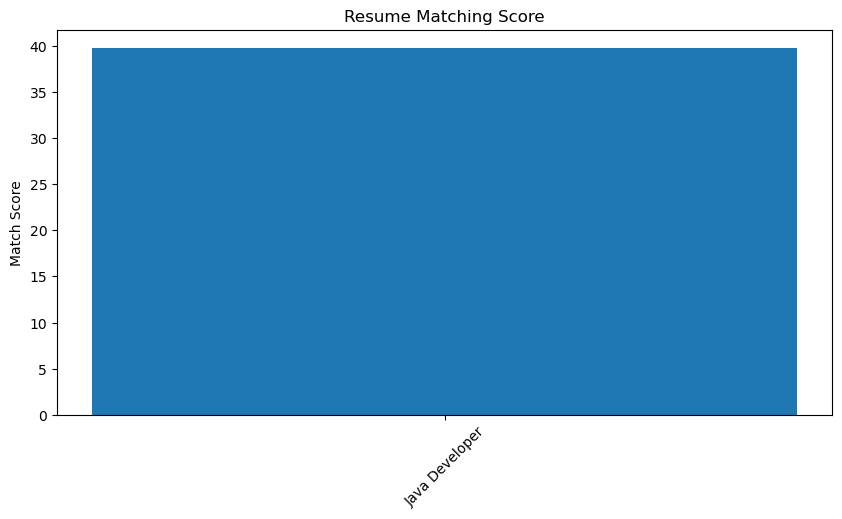

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    result_df["Category"],
    result_df["Match Score"]
)

plt.xticks(rotation=45)

plt.ylabel("Match Score")

plt.title("Resume Matching Score")

plt.show()

## Save Results

In [28]:
import os

os.makedirs("../outputs", exist_ok=True)

result_df.to_csv(
    "../outputs/resume_matching_scores.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully
